# Imports & Data Filtering

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
from scipy.stats import rankdata, norm
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # to minimise output verbosity later

In [2]:
# file paths
DB_PATH = 'human_genome_old.db' 
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'

In [3]:
SAMPLE_ID = 'random_id' 

In [4]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet(GERMLINE_DATA_PATH)
somatic_raw = pd.read_parquet(SOMATIC_DATA_PATH)
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

In [5]:
splicing = pd.read_parquet(SPLICING_DATA_PATH)
outrider = pd.read_parquet(EXPRESSION_DATA_PATH)
protein = pd.read_parquet(PROTEIN_DATA_PATH)

In [6]:
# format ensembl gene ID column to match database
res['geneID_filtered'] = res['Gene'].str.split('.').str[0].str.strip()
outrider['geneID_filtered'] = outrider['geneID_short'].str.split('.').str[0].str.strip()
protein['geneID_filtered'] = protein['geneID_short'].str.split('.').str[0].str.strip()
splicing['geneID_filtered'] = splicing['geneID_short'].str.split('.').str[0].str.strip()

In [7]:
# get generic gene names instead of symbols
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

In [8]:
def map_and_clean_ids(df, id_column):
    df['geneID_filtered'] = df[id_column].astype(str).str.split('.').str[0].str.strip() # just for double security
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    return df

res = map_and_clean_ids(res, 'Gene')
outrider = map_and_clean_ids(outrider, 'geneID_short')
protein = map_and_clean_ids(protein, 'geneID_short')
splicing = map_and_clean_ids(splicing, 'geneID_short')

In [9]:
# map chromosome number to each gene
res['chrom'] = res['seqnames'] # if a column already has the corresponding chromosomes

conn = sqlite3.connect(DB_PATH)
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

# for the dataframes that do not have the chromosomes already mapped
outrider['chrom'] = outrider['geneID_filtered'].map(gene_chrom_map)
protein['chrom'] = protein['geneID_filtered'].map(gene_chrom_map)
splicing['chrom'] = splicing['geneID_filtered'].map(gene_chrom_map)

In [10]:
# matrix of counts per sample per chromosome => needed for chromosome-aware stats test
def get_chrom_counts(outlier_df, sample_id=SAMPLE_ID):
    return outlier_df.groupby([sample_id, 'chrom']).size().unstack(fill_value=0)

all_ids = res[SAMPLE_ID].unique()

chrom_counts_gene = get_chrom_counts(outrider).reindex(all_ids, fill_value=0)
chrom_counts_prot = get_chrom_counts(protein).reindex(all_ids, fill_value=0)
chrom_counts_spl = get_chrom_counts(splicing).reindex(all_ids, fill_value=0)

# for gene + protein overlap
gene_prot_overlap = pd.merge(
    outrider,
    protein,
    on=[SAMPLE_ID, 'geneID_filtered', 'chrom']
).drop_duplicates(subset=[SAMPLE_ID, 'geneID_filtered'])

chrom_counts_gene_prot_overlap = get_chrom_counts(gene_prot_overlap).reindex(all_ids, fill_value=0)

In [11]:
# calculate sample-gene burdens
def calculate_burdens(outrider_df, protein_df, splicing_df, res_df, sample_id=SAMPLE_ID):
    burdens = {}

    burdens['gene'] = outrider_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['protein'] = protein_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['splicing'] = splicing_df.groupby(sample_id)['geneID_filtered'].nunique()

    all_samples = res_df[sample_id].unique()
    return {k: v.reindex(all_samples, fill_value=0).reset_index(name='burden') for k, v in burdens.items()}

In [12]:
# get the testable genes by checking if they have minimum n carriers
def get_testable_genes(outlier_df, res_df, min_carriers=5):
    outlier_genes = set(outlier_df['geneID_filtered'].unique())
    res_filtered = res_df[res_df['geneID_filtered'].isin(outlier_genes)]

    carrier_counts = (
        res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
        ['geneID_filtered']
        .value_counts()
    )

    valid_genes = carrier_counts[carrier_counts >= min_carriers].index.tolist()

    print(f"Total testable genes (conventional names): {len(valid_genes)}")
    return valid_genes

In [13]:
# wilcoxon rank sum test + FDR correction => this test is not chromosome 'aware'
def stats_test_no_chrom_awareness(genes_to_test, res_df, burden_df, filter_sig=True, alpha=0.05):
    if not genes_to_test:
        return pd.DataFrame()

    burden_df = burden_df.copy()
    burden_df['global_rank'] = rankdata(burden_df['burden'])
    N = len(burden_df)

    res_filtered = res_df[res_df['geneID_filtered'].isin(genes_to_test)]
    unique_carriers = res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

    merged = unique_carriers.merge(
        burden_df[[SAMPLE_ID, 'global_rank']],
        on=SAMPLE_ID,
        how='inner'
    )

    stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
        n_carriers='count',
        rank_sum='sum'
    ).reset_index()
    stats_df.rename(columns={'geneID_filtered': 'Gene'}, inplace=True)

    n1 = stats_df['n_carriers']
    n2 = N - n1
    s = stats_df['rank_sum']

    expected = n1 * (N + 1) / 2.0
    std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

    z_scores = (s - expected) / std_dev
    stats_df['p_val'] = norm.sf(z_scores)

    stats_df = stats_df.drop(columns=['rank_sum'])

    if not stats_df.empty:
        _, stats_df['padj'], _, _ = multipletests(stats_df['p_val'], method='fdr_bh')
        #_, stats_df['padj'], _, _ = multipletests(stats_df['p_val'], method='bonferroni')

        if filter_sig:
            return stats_df[stats_df['padj'] < alpha].sort_values('padj')
        else:
            return stats_df.sort_values('p_val')

    return stats_df

# chromosome 'aware' stats test => outliers on the same chromosome as a CNV will be removed
def stats_test(genes_to_test, res_df, chrom_counts_matrix, filter_sig=True, alpha=0.05):
    valid_res = res_df.dropna(subset=['chrom'])

    valid_genes_in_res = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes_in_res]

    results = []

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index
    N = len(all_samples)

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in genes_by_chrom.items():

        current_chrom_outliers = chrom_counts_matrix.get(chrom, 0)
        adj_burden = total_burden_series - current_chrom_outliers

        global_ranks = pd.Series(rankdata(adj_burden), index=all_samples)

        res_subset = valid_res[valid_res['geneID_filtered'].isin(genes)]
        unique_carriers = res_subset.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

        merged = unique_carriers.merge(global_ranks.rename('global_rank'),
                                      left_on=SAMPLE_ID, right_index=True, how='inner')

        stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
            n_carriers='count',
            rank_sum='sum'
        ).reset_index()

        n1 = stats_df['n_carriers']
        n2 = N - n1
        s = stats_df['rank_sum']
        expected = n1 * (N + 1) / 2.0
        std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

        z_scores = (s - expected) / std_dev
        stats_df['p_val'] = norm.sf(z_scores)

        results.append(stats_df)

    if not results:
        return pd.DataFrame()

    final_stats_df = pd.concat(results).rename(columns={'geneID_filtered': 'Gene'})

    if not final_stats_df.empty:
        _, final_stats_df['padj'], _, _ = multipletests(final_stats_df['p_val'], method='fdr_bh')
        #_, final_stats_df['padj'], _, _ = multipletests(final_stats_df['p_val'], method='bonferroni')
        if filter_sig:
            return final_stats_df[final_stats_df['padj'] < alpha].sort_values('padj')
        return final_stats_df.sort_values('p_val')

    return final_stats_df

In [22]:
# burdens dict, needed either for non-chromosome aware stats test or plotting later
burdens_dict = calculate_burdens(outrider, protein, splicing, res)

# gene outliers
genes_gene = get_testable_genes(outrider, res, min_carriers=20)
sig_gene = stats_test(genes_gene, res, chrom_counts_gene, filter_sig=True, alpha=0.01)

# protein outliers
genes_prot = get_testable_genes(protein, res, min_carriers=20)
sig_prot = stats_test(genes_prot, res, chrom_counts_prot, filter_sig=True, alpha=0.1)

# splicing outliers
genes_spl = get_testable_genes(splicing, res, min_carriers=20)
sig_spl = stats_test(genes_spl, res, chrom_counts_spl, filter_sig=True, alpha=0.05)

# gene + protein outliers
genes_gene_prot_overlap = get_testable_genes(gene_prot_overlap, res, min_carriers=5)
sig_gene_prot_overlap = stats_test(genes_gene_prot_overlap, res, chrom_counts_gene_prot_overlap, filter_sig=True, alpha=0.05)

Total testable genes (conventional names): 7076
Total testable genes (conventional names): 1946
Total testable genes (conventional names): 8425
Total testable genes (conventional names): 623


In [23]:
print(f"Significant genes (gene expression): {len(sig_gene)}")
print(f"Significant genes (splicing): {len(sig_spl)}")
print(f"Significant genes (protein): {len(sig_prot)}")
print(f"Significant genes (gene & protein overlap): {len(sig_gene_prot_overlap)}")

Significant genes (gene expression): 1249
Significant genes (splicing): 0
Significant genes (protein): 0
Significant genes (gene & protein overlap): 0


In [24]:
# plot the results of the top n most significant genes
def plot_sig_gene_results(gene_list, res_df, burden_df, stats_df):
    for gene in gene_list:
        gene_stats = stats_df[stats_df['Gene'] == gene].iloc[0]
        p_val = gene_stats['p_val']
        p_adj = gene_stats['padj']

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])

            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()

            type_label = "/".join(sorted(types))
            return f"{origin_label} ({type_label})"

        variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='Variant_Detail')

        df_plot = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        df_plot['Group'] = np.where(df_plot['Variant_Detail'].isna(), 'No CNV', 'Has CNV')
        df_plot['Variant_Detail'] = df_plot['Variant_Detail'].fillna('No Variant')

        plt.figure(figsize=(10, 7))

        sns.boxplot(data=df_plot, x='Group', y='burden',
                    palette={'No CNV': '#f5f5f5', 'Has CNV': 'white'},
                    order=['No CNV', 'Has CNV'], showfliers=False, width=0.5)

        unique_variants = [v for v in df_plot['Variant_Detail'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=df_plot, x='Group', y='burden',
                      hue='Variant_Detail',
                      palette=palette_dict,
                      order=['No CNV', 'Has CNV'],
                      jitter=True, s=8, alpha=0.7)

        plt.title(f"{gene}\n"
                  f"(p: {p_val:.2e}, p adj: {p_adj:.2e})",
                  fontsize=15, pad=20)

        plt.ylabel("Number of gene expression outliers", fontsize=12)
        plt.xlabel("")

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        plt.legend([handles[i] for i in filtered_indices],
                   [labels[i] for i in filtered_indices],
                   title="Origin & Type of Mutation",
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        n_wt = len(df_plot[df_plot['Group'] == 'No CNV'])
        n_carrier = len(df_plot[df_plot['Group'] == 'Has CNV'])
        plt.xticks([0, 1], [f'No CNV\n(n={n_wt})', f'Has CNV\n(n={n_carrier})'])

        plt.tight_layout()
        #plt.savefig(f'chrom_aware_gene_outliers_{gene}.png', dpi=300)
        plt.show()

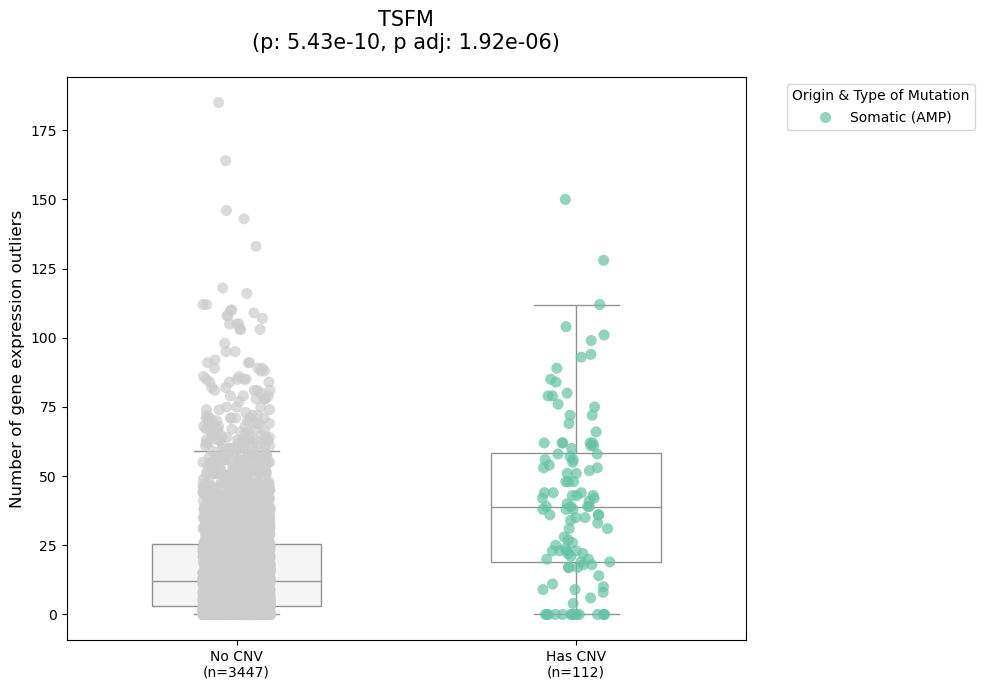

In [25]:
top_n_genes = sig_gene.head(1)['Gene'].tolist()
plot_sig_gene_results(top_n_genes, res, burdens_dict['gene'], sig_gene)

# Cohen's d & COSMIC Genes

In [26]:
num_sig_genes = len(sig_gene)
print(f"Total significant genes (FDR < 0.05): {num_sig_genes}")

cosmic_path = 'Cosmic_CancerGeneCensus_v103_GRCh37.tsv'
cosmic_df = pd.read_csv(cosmic_path, sep='\t')
cosmic_genes = set(cosmic_df['GENE_SYMBOL'])

sig_gene['in_COSMIC'] = sig_gene['Gene'].isin(cosmic_genes)
num_in_cosmic = sig_gene['in_COSMIC'].sum()
print(f"Significant genes in COSMIC: {num_in_cosmic}")

Total significant genes (FDR < 0.05): 1249
Significant genes in COSMIC: 73


In [27]:
def get_cohens_d(gene, res_df, burden_df):
    carriers = res_df[res_df['geneID_filtered'] == gene][SAMPLE_ID].unique()
    
    carrier_burden = burden_df[burden_df[SAMPLE_ID].isin(carriers)]['burden'].values
    wt_burden = burden_df[~burden_df[SAMPLE_ID].isin(carriers)]['burden'].values
    
    n1, n2 = len(carrier_burden), len(wt_burden)
    
    if n1 < 2 or n2 < 2:
        return np.nan
        
    var1, var2 = np.var(carrier_burden, ddof=1), np.var(wt_burden, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
        
    return (np.mean(carrier_burden) - np.mean(wt_burden)) / pooled_std

In [28]:
burden_df = burdens_dict['gene'] 
sig_gene['cohens_d'] = sig_gene['Gene'].apply(lambda g: get_cohens_d(g, res, burden_df))
strong_effect_genes = sig_gene[sig_gene['cohens_d'].abs() >= 0.5].sort_values(by='cohens_d', ascending=False)

In [29]:
len(strong_effect_genes)

996

In [30]:
strong_effect_genes['in_COSMIC'] = strong_effect_genes['Gene'].isin(cosmic_genes)
num_in_cosmic = strong_effect_genes['in_COSMIC'].sum()
print(f"Significant genes in COSMIC: {num_in_cosmic}")

Significant genes in COSMIC: 56


In [31]:
# testing against using the stats test with no chromosome awareness 
sig_gene_no_chrom = stats_test_no_chrom_awareness(genes_gene, res, burdens_dict['gene'], alpha=0.01)
num_sig_genes_no_chrom = len(sig_gene_no_chrom)
print(f"Total significant genes (FDR < 0.05): {num_sig_genes_no_chrom}")

sig_gene_no_chrom['in_COSMIC'] = sig_gene_no_chrom['Gene'].isin(cosmic_genes)
num_in_cosmic_no_chrom = sig_gene_no_chrom['in_COSMIC'].sum()
print(f"Significant genes in COSMIC: {num_in_cosmic_no_chrom}")

sig_gene_no_chrom['cohens_d'] = sig_gene_no_chrom['Gene'].apply(lambda g: get_cohens_d(g, res, burden_df))
strong_effect_genes_no_chrom = sig_gene_no_chrom[sig_gene_no_chrom['cohens_d'].abs() >= 0.5].sort_values(by='cohens_d', ascending=False)

Total significant genes (FDR < 0.05): 2571
Significant genes in COSMIC: 147


In [32]:
len(strong_effect_genes_no_chrom)

1798

In [33]:
strong_effect_genes_no_chrom['in_COSMIC'] = strong_effect_genes_no_chrom['Gene'].isin(cosmic_genes)
num_in_cosmic_no_chrom = strong_effect_genes_no_chrom['in_COSMIC'].sum()
print(f"Significant genes in COSMIC: {num_in_cosmic_no_chrom}")

Significant genes in COSMIC: 102


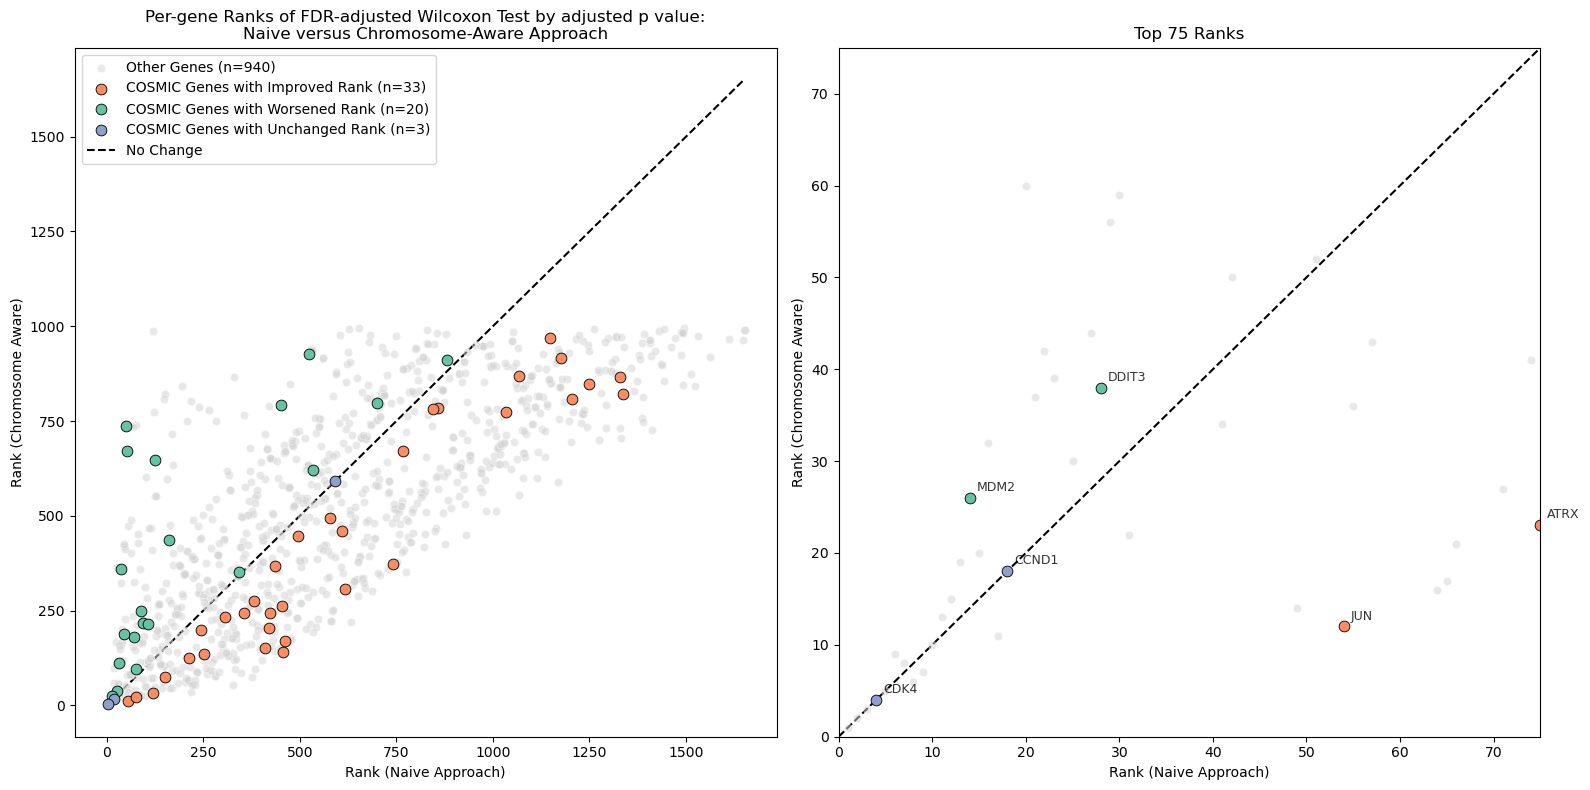

In [34]:
df_no_chrom = strong_effect_genes_no_chrom.copy()
df_chrom = strong_effect_genes.copy()

df_no_chrom['rank_no_chrom'] = df_no_chrom['padj'].rank(method='first')
df_chrom['rank_chrom'] = df_chrom['padj'].rank(method='first')

merged = df_no_chrom[['Gene', 'rank_no_chrom', 'in_COSMIC']].merge(
    df_chrom[['Gene', 'rank_chrom']], 
    on='Gene', 
    how='inner'
)

other = merged[merged['in_COSMIC'] == False]
cosmic_imp = merged[(merged['in_COSMIC'] == True) & (merged['rank_chrom'] < merged['rank_no_chrom'])]
cosmic_wor = merged[(merged['in_COSMIC'] == True) & (merged['rank_chrom'] > merged['rank_no_chrom'])]
cosmic_same = merged[(merged['in_COSMIC'] == True) & (merged['rank_chrom'] == merged['rank_no_chrom'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.scatterplot(
    ax=axes[0], data=other, x='rank_no_chrom', y='rank_chrom',
    color='lightgray', alpha=0.5, label=f'Other Genes (n={len(other)})'
)

if not cosmic_imp.empty:
    sns.scatterplot(
        ax=axes[0], data=cosmic_imp, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[1], s=60, edgecolor='black', label=f'COSMIC Genes with Improved Rank (n={len(cosmic_imp)})'
    )

if not cosmic_wor.empty:
    sns.scatterplot(
        ax=axes[0], data=cosmic_wor, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[0], s=60, edgecolor='black', label=f'COSMIC Genes with Worsened Rank (n={len(cosmic_wor)})'
    )

if not cosmic_same.empty:
    sns.scatterplot(
        ax=axes[0], data=cosmic_same, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[2], s=60, edgecolor='black', label=f'COSMIC Genes with Unchanged Rank (n={len(cosmic_same)})'
    )

max_rank = max(merged['rank_no_chrom'].max(), merged['rank_chrom'].max())
axes[0].plot([0, max_rank], [0, max_rank], 'k--', zorder=0, label='No Change')

axes[0].legend(loc='upper left')
axes[0].set_title('Per-gene Ranks of FDR-adjusted Wilcoxon Test by adjusted p value:\nNaive versus Chromosome-Aware Approach')
axes[0].set_xlabel('Rank (Naive Approach)')
axes[0].set_ylabel('Rank (Chromosome Aware)')

sns.scatterplot(
    ax=axes[1], data=other, x='rank_no_chrom', y='rank_chrom',
    color='lightgray', alpha=0.5
)

if not cosmic_imp.empty:
    sns.scatterplot(
        ax=axes[1], data=cosmic_imp, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[1], s=60, edgecolor='black'
    )

if not cosmic_wor.empty:
    sns.scatterplot(
        ax=axes[1], data=cosmic_wor, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[0], s=60, edgecolor='black'
    )

if not cosmic_same.empty:
    sns.scatterplot(
        ax=axes[1], data=cosmic_same, x='rank_no_chrom', y='rank_chrom',
        color=sns.color_palette("Set2")[2], s=60, edgecolor='black'
    )

axes[1].plot([0, 75], [0, 75], 'k--', zorder=0)
axes[1].set_xlim(0, 75)
axes[1].set_ylim(0, 75)

label_df = merged[
    (merged['in_COSMIC'] == True) & 
    ((merged['rank_no_chrom'] <= 75) | (merged['rank_chrom'] <= 75))
]

for _, row in label_df.iterrows():
    axes[1].annotate(
        row['Gene'], 
        (row['rank_no_chrom'], row['rank_chrom']),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

axes[1].set_title('Top 75 Ranks')
axes[1].set_xlabel('Rank (Naive Approach)')
axes[1].set_ylabel('Rank (Chromosome Aware)')

plt.tight_layout()
plt.show()

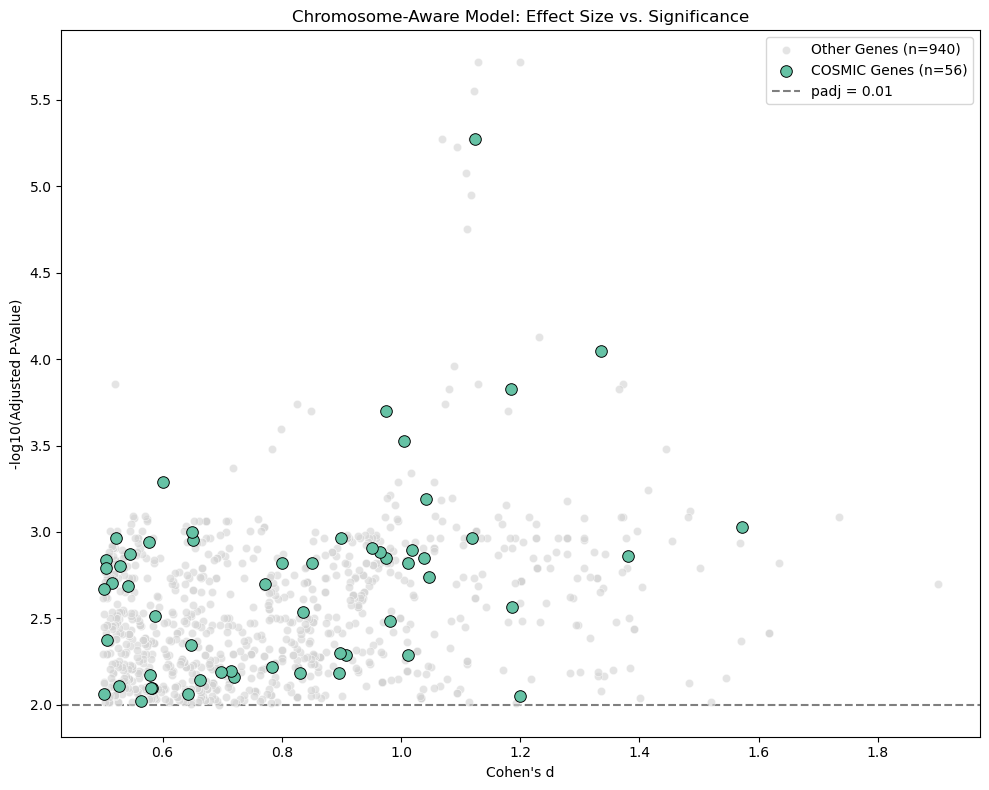

In [35]:
df_chrom = strong_effect_genes.copy()
df_chrom['nlog10_padj'] = -np.log10(df_chrom['padj'])

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_chrom[df_chrom['in_COSMIC'] == False],
    x='cohens_d', 
    y='nlog10_padj',
    color='lightgray', 
    alpha=0.6,
    label=f"Other Genes (n={(df_chrom['in_COSMIC'] == False).sum()})"
)

sns.scatterplot(
    data=df_chrom[df_chrom['in_COSMIC'] == True],
    x='cohens_d', 
    y='nlog10_padj',
    color=sns.color_palette("Set2")[0], 
    s=70, 
    edgecolor='black',
    label=f"COSMIC Genes (n={(df_chrom['in_COSMIC'] == True).sum()})"
)

plt.axhline(-np.log10(0.01), color='k', linestyle='--', alpha=0.5, zorder=0, label='padj = 0.01')

plt.title("Chromosome-Aware Model: Effect Size vs. Significance")
plt.xlabel("Cohen's d")
plt.ylabel("-log10(Adjusted P-Value)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()